In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")
print(df.shape)
print(df.head())

(800, 26)
  company_number company_status  \
0       NI039509         active   
1       NI038794         active   
2       NI043769         active   
3       NI047536         active   
4       NI050108         active   

                                    company_type incorporation_date  \
0  private-limited-guarant-nsc-limited-exemption         2000-10-25   
1                                            ltd         2000-06-15   
2                                            ltd         2002-08-01   
3                                            ltd         2003-08-12   
4                                            ltd         2004-03-30   

  dissolution_date  age_days  sic_primary               sic_sector  \
0              NaN      9326      88990.0  Public/Education/Health   
1       2013-01-04      4586       4521.0            Manufacturing   
2       2013-10-10      4088       7415.0            Manufacturing   
3       2013-11-08      3741      43390.0   Construction/Transport   
4 

In [31]:
print("Class balance:")
print(df["dissolved"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nCompany types:")
print(df["company_type"].value_counts())

Class balance:
dissolved
0    400
1    400
Name: count, dtype: int64

Missing values:
company_number                0
company_status                0
company_type                  0
incorporation_date            0
dissolution_date            299
age_days                      0
sic_primary                 353
sic_sector                    0
region                        0
has_insolvency_history        0
has_charges                   0
has_been_liquidated           0
office_in_dispute             0
undeliverable_address         0
officer_count                 0
resigned_count                0
officer_turnover_rate         0
filing_count                  0
accounts_count                0
confirmation_count            0
charge_count                  0
outstanding_charges           0
charge_satisfaction_rate      0
psc_count                     0
corporate_psc_count           0
dissolved                     0
dtype: int64

Company types:
company_type
ltd                                     

In [32]:
print("SIC missing by status:")
print(df.groupby("dissolved")["sic_primary"].apply(lambda x: x.isnull().sum()))

print("\nRegion distribution:")
print(df["region"].value_counts().head(10))

print("\nNumeric summary:")
print(df.describe())

SIC missing by status:
dissolved
0    292
1     61
Name: sic_primary, dtype: int64

Region distribution:
region
Belfast          148
County Down       68
Edinburgh         56
Co Down           40
Unknown           30
London            27
Antrim            27
County Antrim     20
Co Antrim         18
Co Tyrone         14
Name: count, dtype: int64

Numeric summary:
          age_days   sic_primary  has_insolvency_history  has_charges  \
count   800.000000    447.000000              800.000000    800.00000   
mean   4299.712500  58861.378076                0.131250      0.16250   
std    2584.052071  25842.939930                0.337885      0.36914   
min     229.000000   1130.000000                0.000000      0.00000   
25%    2346.000000  41202.000000                0.000000      0.00000   
50%    3736.000000  62012.000000                0.000000      0.00000   
75%    6072.250000  77749.500000                0.000000      0.00000   
max    9612.000000  99999.000000                1.

In [33]:
# Plot styling
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

df = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 800 rows, 26 columns


,company_number,company_status,company_type,incorporation_date,dissolution_date,age_days,sic_primary,sic_sector,region,has_insolvency_history,...,officer_turnover_rate,filing_count,accounts_count,confirmation_count,charge_count,outstanding_charges,charge_satisfaction_rate,psc_count,corporate_psc_count,dissolved
0,NI039509,active,private-limited-guarant-nsc-limited-exemption,2000-10-25,NaN,9326,88990.0,Public/Education/Health,Newtownabbey,0,...,0.929,85,21,21,0,0,0.000,0,0,0
1,NI038794,active,ltd,2000-06-15,2013-01-04,4586,4521.0,Manufacturing,Carrickfergus,0,...,0.500,43,11,11,1,1,0.000,0,0,0
2,NI043769,active,ltd,2002-08-01,2013-10-10,4088,7415.0,Manufacturing,Co Down,1,...,0.500,59,8,8,3,1,0.667,0,0,0
3,NI047536,active,ltd,2003-08-12,2013-11-08,3741,43390.0,Construction/Transport,County Antrim,0,...,0.000,35,10,9,1,1,0.000,0,0,0
4,NI050108,active,ltd,2004-03-30,2016-06-28,4473,70229.0,Real Estate/Business,Belfast,0,...,0.000,37,12,11,0,0,0.000,0,0,0


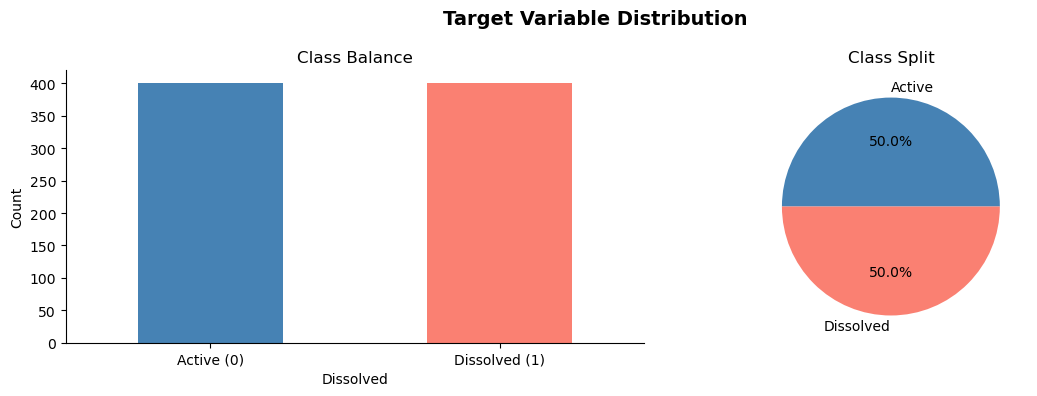

dissolved
0    400
1    400
Name: count, dtype: int64

Balance ratio: 0.50


In [34]:
# ── 1. Class Balance ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df["dissolved"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Dissolved")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Active (0)", "Dissolved (1)"], rotation=0)

# Pie chart
df["dissolved"].value_counts().plot(kind="pie", ax=axes[1], 
    labels=["Active", "Dissolved"], autopct="%1.1f%%", colors=["steelblue", "salmon"])
axes[1].set_ylabel("")
axes[1].set_title("Class Split")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\class_balance.png", dpi=150)
plt.show()

print(df["dissolved"].value_counts())
print(f"\nBalance ratio: {df['dissolved'].mean():.2f}")

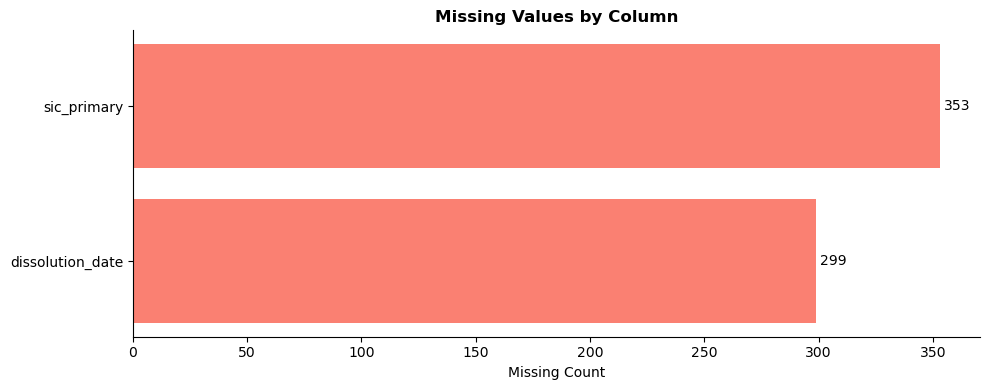

Missing values as % of dataset:
sic_primary         44.1
dissolution_date    37.4


In [35]:
# ── 2. Missing Values ─────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values, color="salmon")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Missing Count")
ax.set_title("Missing Values by Column", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\missing_values.png", dpi=150)
plt.show()

# Show missing as percentage
print("Missing values as % of dataset:")
print((missing / len(df) * 100).round(1).to_string())

In [36]:
# ── 3. Clean the Data ─────────────────────────────────────────────────────────

# 1. sic_primary — fill missing with 0, add a flag column
df["sic_missing"] = df["sic_primary"].isnull().astype(int)
df["sic_primary"] = df["sic_primary"].fillna(0)

# 2. dissolution_date — missing means active, that's fine, drop the column
#    (we already have age_days which captures this info)
df = df.drop(columns=["dissolution_date", "incorporation_date"])

# 3. Clean up region duplicates (Belfast area has multiple labels)
region_map = {
    "Co Down": "County Down",
    "Co Antrim": "County Antrim", 
    "Co Tyrone": "County Tyrone",
    "Co Armagh": "County Armagh",
    "Co Londonderry": "County Londonderry",
    "Co Fermanagh": "County Fermanagh",
}
df["region"] = df["region"].replace(region_map)

# 4. Drop columns not useful for modelling
df = df.drop(columns=["company_number", "company_status", "sic_primary"])

print("Cleaned dataset shape:", df.shape)
print("\nRemaining missing values:", df.isnull().sum().sum())
print("\nColumns:", list(df.columns))

Cleaned dataset shape: (800, 22)

Remaining missing values: 0

Columns: ['company_type', 'age_days', 'sic_sector', 'region', 'has_insolvency_history', 'has_charges', 'has_been_liquidated', 'office_in_dispute', 'undeliverable_address', 'officer_count', 'resigned_count', 'officer_turnover_rate', 'filing_count', 'accounts_count', 'confirmation_count', 'charge_count', 'outstanding_charges', 'charge_satisfaction_rate', 'psc_count', 'corporate_psc_count', 'dissolved', 'sic_missing']


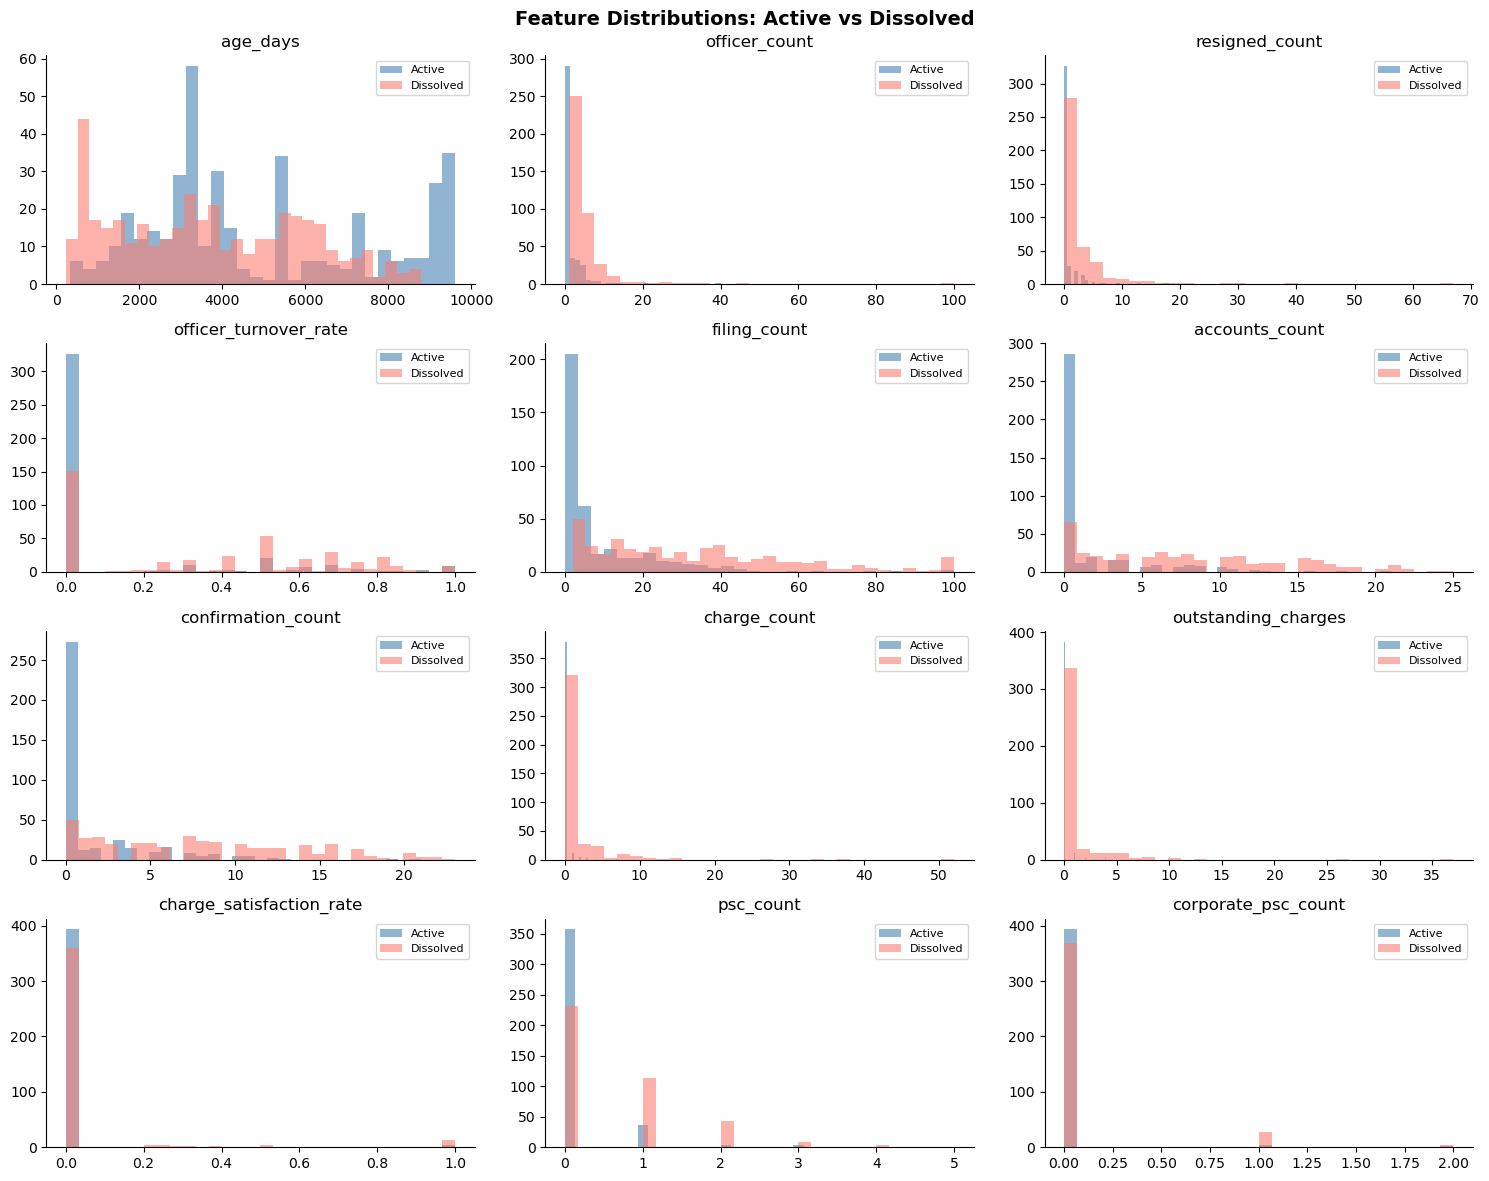

In [37]:
# ── 4. Numeric Feature Distributions ─────────────────────────────────────────
numeric_cols = [
    "age_days", "officer_count", "resigned_count", "officer_turnover_rate",
    "filing_count", "accounts_count", "confirmation_count", "charge_count",
    "outstanding_charges", "charge_satisfaction_rate", "psc_count", "corporate_psc_count"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[df["dissolved"]==0][col], bins=30, alpha=0.6, 
                 color="steelblue", label="Active")
    axes[i].hist(df[df["dissolved"]==1][col], bins=30, alpha=0.6, 
                 color="salmon", label="Dissolved")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Active vs Dissolved", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\feature_distributions.png", dpi=150)
plt.show()

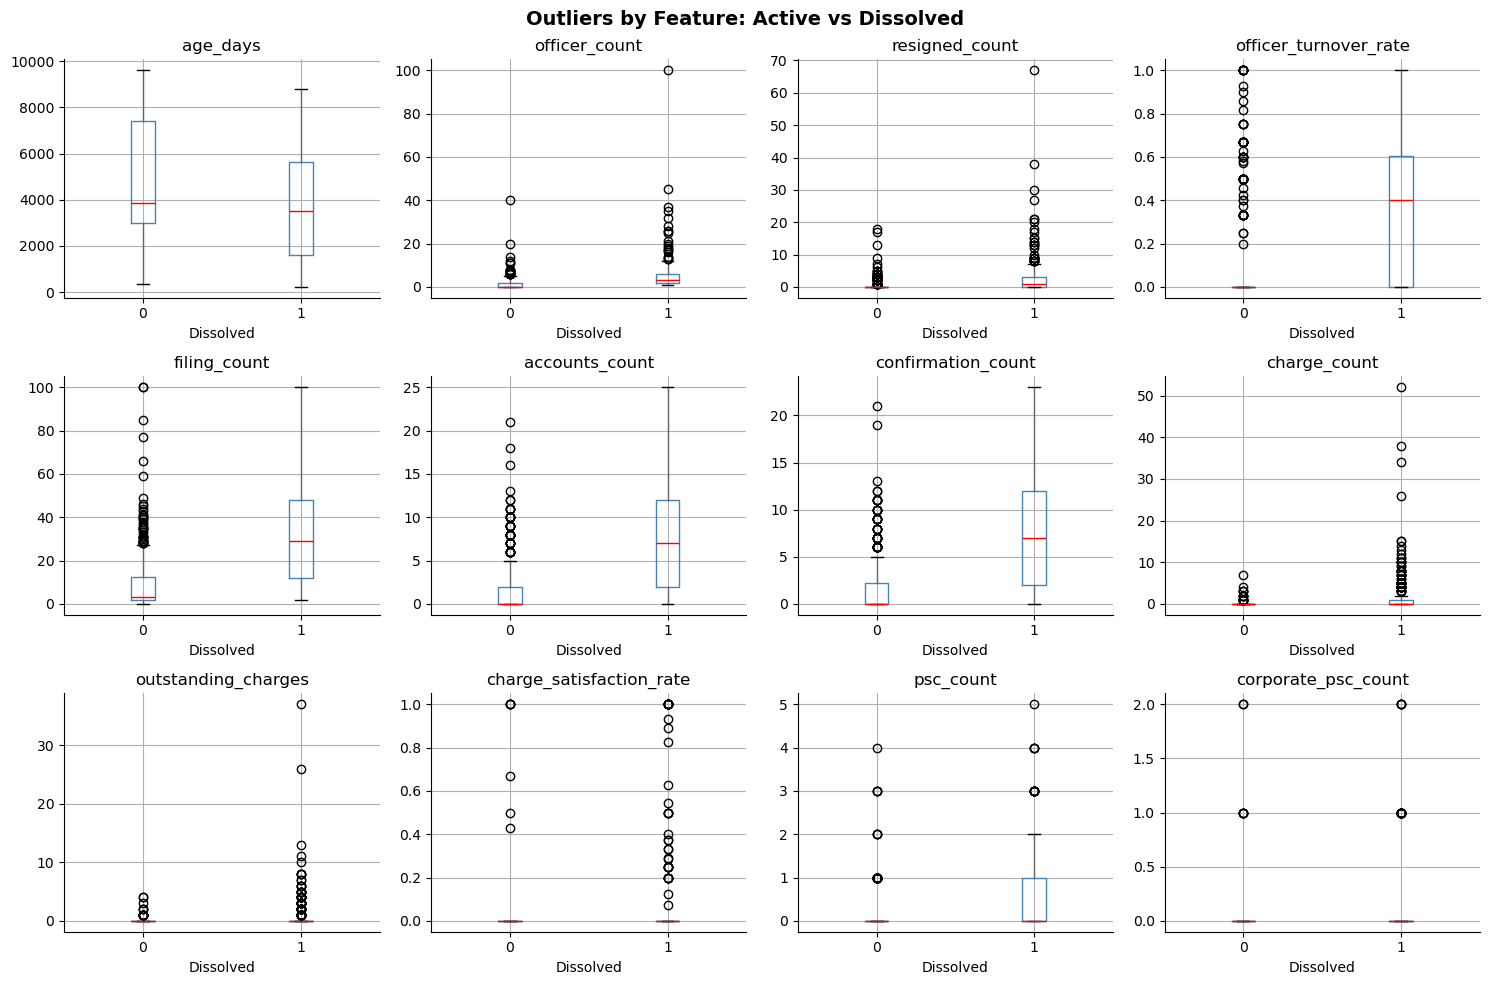

In [38]:
# ── 5. Boxplots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by="dissolved", ax=axes[i], 
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red"))
    axes[i].set_title(col)
    axes[i].set_xlabel("Dissolved")

plt.suptitle("Outliers by Feature: Active vs Dissolved", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\boxplots.png", dpi=150)
plt.show()

In [39]:
# ── 6. Cap Outliers ───────────────────────────────────────────────────────────
cap_cols = {
    "officer_count": 20,
    "resigned_count": 20,
    "filing_count": 60,
    "accounts_count": 20,
    "confirmation_count": 20,
    "charge_count": 10,
    "outstanding_charges": 10,
}

for col, cap in cap_cols.items():
    df[col] = df[col].clip(upper=cap)

print("Outliers capped.")
print(df[list(cap_cols.keys())].describe().loc[["max"]].round(1))

Outliers capped.
     officer_count  resigned_count  filing_count  accounts_count  \
max           20.0            20.0          60.0            20.0   

     confirmation_count  charge_count  outstanding_charges  
max                20.0          10.0                 10.0  


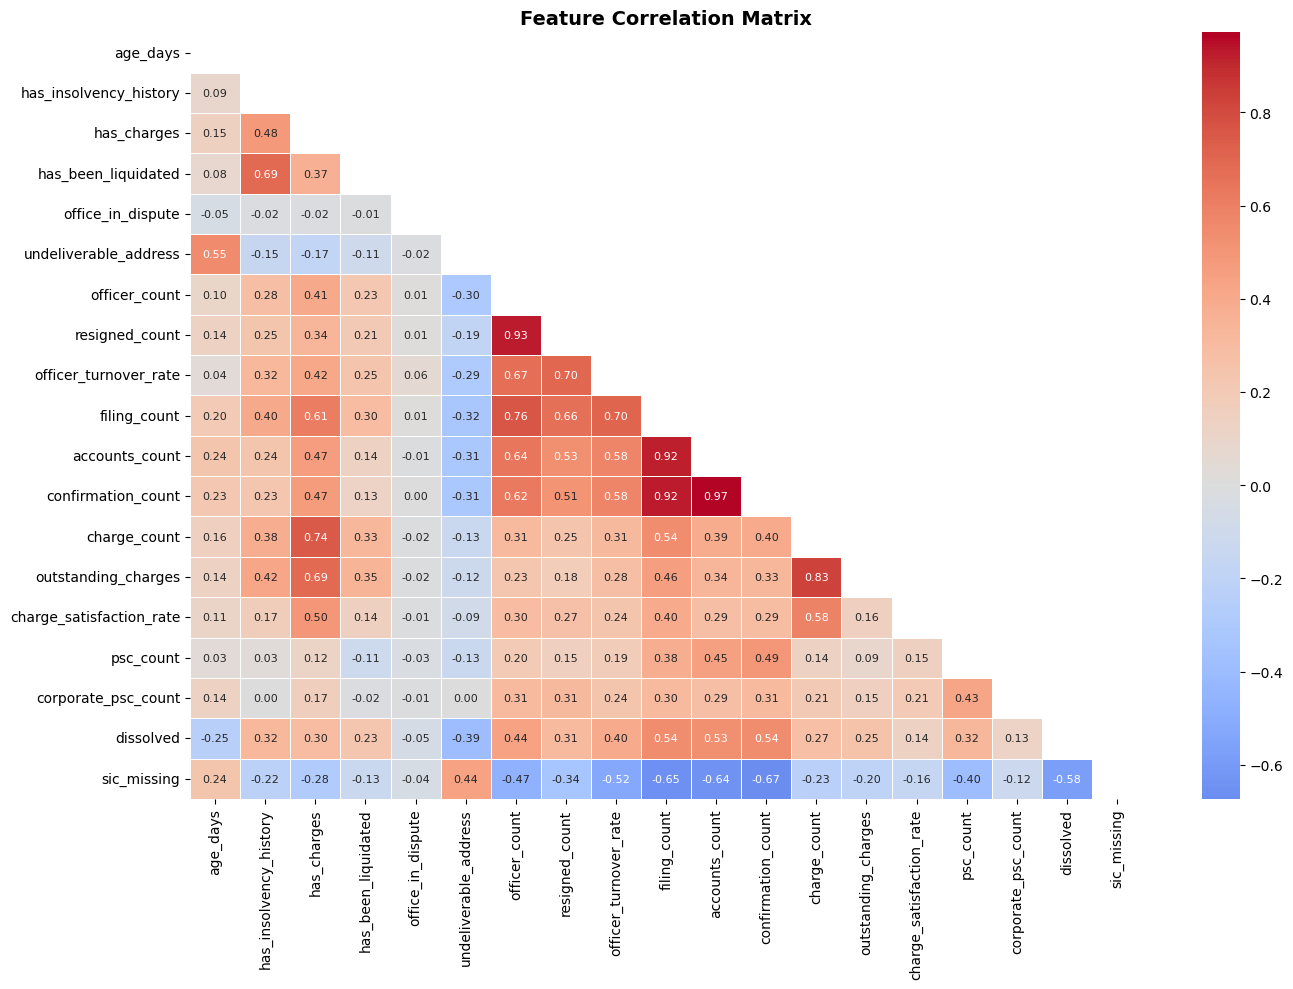

In [40]:
# ── 7. Correlation Heatmap ────────────────────────────────────────────────────
numeric_df = df.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\correlation_heatmap.png", dpi=150)
plt.show()

In [41]:
# ── 8. Drop Highly Correlated Features ───────────────────────────────────────
# Keep the more interpretable of each correlated pair
df = df.drop(columns=["confirmation_count", "resigned_count", "accounts_count"])

print("Remaining columns:", list(df.columns))
print("Shape:", df.shape)

Remaining columns: ['company_type', 'age_days', 'sic_sector', 'region', 'has_insolvency_history', 'has_charges', 'has_been_liquidated', 'office_in_dispute', 'undeliverable_address', 'officer_count', 'officer_turnover_rate', 'filing_count', 'charge_count', 'outstanding_charges', 'charge_satisfaction_rate', 'psc_count', 'corporate_psc_count', 'dissolved', 'sic_missing']
Shape: (800, 19)


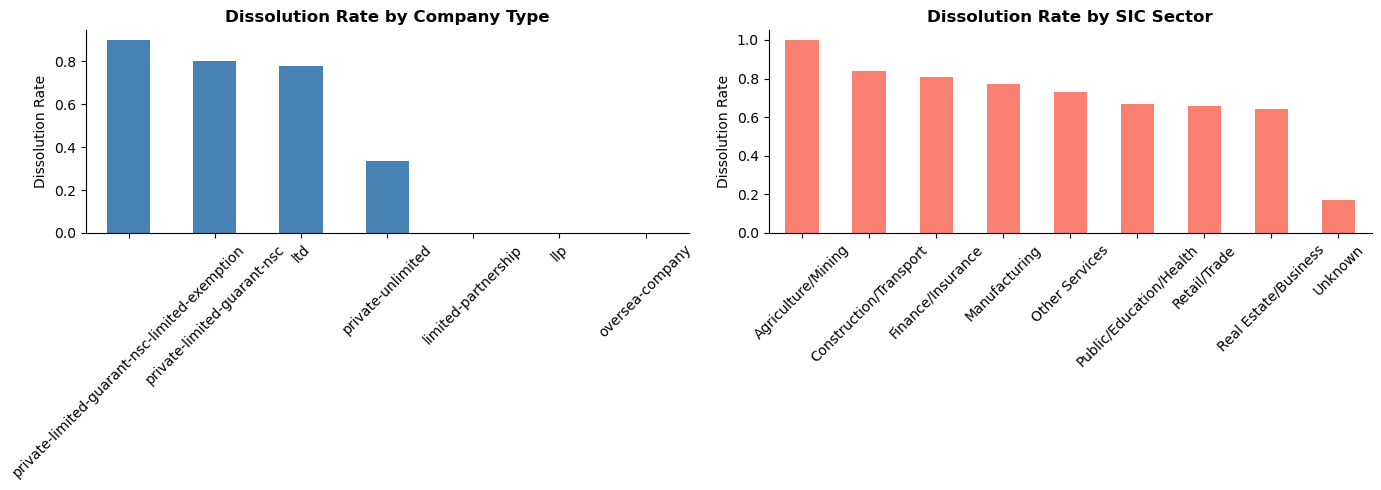

In [42]:
# ── 9. Categorical Feature Analysis ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Company type vs dissolution rate
type_dissolve = df.groupby("company_type")["dissolved"].mean().sort_values(ascending=False)
type_dissolve.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Dissolution Rate by Company Type", fontweight="bold")
axes[0].set_ylabel("Dissolution Rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# SIC sector vs dissolution rate
sector_dissolve = df.groupby("sic_sector")["dissolved"].mean().sort_values(ascending=False)
sector_dissolve.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Dissolution Rate by SIC Sector", fontweight="bold")
axes[1].set_ylabel("Dissolution Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\categorical_features.png", dpi=150)
plt.show()

In [43]:
# ── 10. Encode Categoricals ───────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

# One-hot encode company_type and sic_sector
df_ml = pd.get_dummies(df, columns=["company_type", "sic_sector", "region"], 
                        drop_first=True)

print("ML-ready shape:", df_ml.shape)
print("Columns:", list(df_ml.columns))

# Save ML-ready dataset
df_ml.to_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_ml.csv", index=False)
print("\nSaved companies_ml.csv")

ML-ready shape: (800, 178)
Columns: ['age_days', 'has_insolvency_history', 'has_charges', 'has_been_liquidated', 'office_in_dispute', 'undeliverable_address', 'officer_count', 'officer_turnover_rate', 'filing_count', 'charge_count', 'outstanding_charges', 'charge_satisfaction_rate', 'psc_count', 'corporate_psc_count', 'dissolved', 'sic_missing', 'company_type_llp', 'company_type_ltd', 'company_type_oversea-company', 'company_type_private-limited-guarant-nsc', 'company_type_private-limited-guarant-nsc-limited-exemption', 'company_type_private-unlimited', 'sic_sector_Construction/Transport', 'sic_sector_Finance/Insurance', 'sic_sector_Manufacturing', 'sic_sector_Other Services', 'sic_sector_Public/Education/Health', 'sic_sector_Real Estate/Business', 'sic_sector_Retail/Trade', 'sic_sector_Unknown', 'region_95054 Usa', 'region_Aberdeen', 'region_Aberdeenshire', 'region_Annan', 'region_Antrim', 'region_Argyll', 'region_Armagh', 'region_Ayr', 'region_Ayrshire', 'region_Ballyclare', 'region_

In [44]:
# ── Fix Region ────────────────────────────────────────────────────────────────
# Reload the pre-encoded df (before get_dummies)
df_clean = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")

# Redo the cleaning steps
df_clean["sic_missing"] = df_clean["sic_primary"].isnull().astype(int)
df_clean["sic_primary"] = df_clean["sic_primary"].fillna(0)
df_clean = df_clean.drop(columns=["dissolution_date", "incorporation_date", 
                                   "company_number", "company_status", "sic_primary",
                                   "confirmation_count", "resigned_count", "accounts_count"])

# Aggressively clean region into broad buckets
def clean_region(r):
    r = str(r).lower().strip().replace("co.", "county").replace("co ", "county ")
    if any(x in r for x in ["antrim", "belfast", "ballymena", "ballyclare", 
                              "carrickfergus", "larne", "newtownabbey"]):
        return "County Antrim"
    if any(x in r for x in ["down", "bangor", "newry", "carryduff", "holywood"]):
        return "County Down"
    if any(x in r for x in ["londonderry", "derry", "coleraine", "limavady", "magherafelt"]):
        return "County Londonderry"
    if any(x in r for x in ["tyrone", "omagh", "dungannon", "cookstown", "strabane"]):
        return "County Tyrone"
    if any(x in r for x in ["armagh", "portadown", "craigavon", "banbridge"]):
        return "County Armagh"
    if any(x in r for x in ["fermanagh", "enniskillen"]):
        return "County Fermanagh"
    if any(x in r for x in ["edinburgh", "glasgow", "scotland", "aberdeen", 
                              "midlothian", "ayr", "perthshire"]):
        return "Scotland"
    if any(x in r for x in ["london", "essex", "kent", "surrey", "middlesex",
                              "hertfordshire", "berkshire", "buckinghamshire"]):
        return "London/SE England"
    if any(x in r for x in ["manchester", "lancashire", "yorkshire", "merseyside",
                              "birmingham", "midlands", "cheshire"]):
        return "England Other"
    if any(x in r for x in ["wales", "cardiff", "swansea", "cwmbran"]):
        return "Wales"
    if any(x in r for x in ["usa", "canada", "netherlands", "norway", 
                              "south africa", "jersey", "guernsey", "isle of man",
                              "channel islands", "british virgin"]):
        return "International"
    if "unknown" in r or "northern ireland" in r or "n ireland" in r or "n. ireland" in r:
        return "Unknown/NI"
    return "Other"

df_clean["region_clean"] = df_clean["region"].apply(clean_region)

print("Region distribution after cleaning:")
print(df_clean["region_clean"].value_counts())
print(f"\nUnique regions: {df_clean['region_clean'].nunique()}")

Region distribution after cleaning:
region_clean
County Antrim         244
County Down           143
Other                  85
Scotland               72
Unknown/NI             44
London/SE England      43
County Tyrone          42
County Londonderry     37
County Armagh          28
England Other          26
International          19
County Fermanagh       12
Wales                   5
Name: count, dtype: int64

Unique regions: 13


In [45]:
# ── Re-encode and Save Clean ML Dataset ──────────────────────────────────────
df_clean = df_clean.drop(columns=["region"])

df_ml = pd.get_dummies(df_clean, columns=["company_type", "sic_sector", "region_clean"],
                        drop_first=True)

print("Final ML-ready shape:", df_ml.shape)
print("\nColumns:", list(df_ml.columns))

# Save
df_ml.to_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_ml.csv", index=False)
print("\nSaved companies_ml.csv")

Final ML-ready shape: (800, 42)

Columns: ['age_days', 'has_insolvency_history', 'has_charges', 'has_been_liquidated', 'office_in_dispute', 'undeliverable_address', 'officer_count', 'officer_turnover_rate', 'filing_count', 'charge_count', 'outstanding_charges', 'charge_satisfaction_rate', 'psc_count', 'corporate_psc_count', 'dissolved', 'sic_missing', 'company_type_llp', 'company_type_ltd', 'company_type_oversea-company', 'company_type_private-limited-guarant-nsc', 'company_type_private-limited-guarant-nsc-limited-exemption', 'company_type_private-unlimited', 'sic_sector_Construction/Transport', 'sic_sector_Finance/Insurance', 'sic_sector_Manufacturing', 'sic_sector_Other Services', 'sic_sector_Public/Education/Health', 'sic_sector_Real Estate/Business', 'sic_sector_Retail/Trade', 'sic_sector_Unknown', 'region_clean_County Armagh', 'region_clean_County Down', 'region_clean_County Fermanagh', 'region_clean_County Londonderry', 'region_clean_County Tyrone', 'region_clean_England Other', 

In [47]:
# ── 11. EDA Summary ───────────────────────────────────────────────────────────
summary = {
    "Total companies": len(df),
    "Active": (df["dissolved"] == 0).sum(),
    "Dissolved": (df["dissolved"] == 1).sum(),
    "Features after cleaning": df.shape[1] - 1,
    "Strongest predictors": [
        "sic_missing (-0.58)",
        "filing_count (0.54)",
        "accounts_count (0.53)", 
        "undeliverable_address (-0.39)",
        "officer_turnover_rate (0.40)"
    ],
    "Multicollinearity removed": [
        "confirmation_count",
        "resigned_count", 
        "accounts_count"
    ]
}

for k, v in summary.items():
    print(f"{k}: {v}")

Total companies: 800
Active: 400
Dissolved: 400
Features after cleaning: 18
Strongest predictors: ['sic_missing (-0.58)', 'filing_count (0.54)', 'accounts_count (0.53)', 'undeliverable_address (-0.39)', 'officer_turnover_rate (0.40)']
Multicollinearity removed: ['confirmation_count', 'resigned_count', 'accounts_count']
